In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [18]:
!wget https://archive.ics.uci.edu/static/public/20/census+income.zip


--2025-04-09 14:47:58--  https://archive.ics.uci.edu/static/public/20/census+income.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘census+income.zip’

census+income.zip       [ <=>                ] 650.11K  3.49MB/s    in 0.2s    

2025-04-09 14:47:59 (3.49 MB/s) - ‘census+income.zip’ saved [665715]



In [19]:
!unzip census+income.zip

Archive:  census+income.zip
  inflating: adult.data              
  inflating: adult.names             
  inflating: adult.test              
  inflating: Index                   
  inflating: old.adult.names         


In [30]:
import pandas as pd

df = pd.read_csv('adult.data', names = ['age','workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
print(len(df))
df

32561


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [31]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [37]:
import numpy as np
import torch

def concatenate_text(x):
    
    text = "".join([f"I have information about a person. ",
            f"He is {x['age']} years old. ",
            f"His sex is {x['sex']}. ",
            f"His workclass is {x['workclass']}. ",
            f"There are approximately {x['fnlwgt']} people in the US like him. ",
            f"His education is {x['education']}. ",
            f"His education duration is {x['education-num']} years. ",
            f"His marital status is {x['marital-status']}. ",
            f"His occupation is {x['occupation']}. ",
            f"His relationship is {x['relationship']}. ",
            f"His race is {x['race']}. ",
            f"His capital gain is {x['capital-gain']}. ",
            f"His capital loss is {x['capital-loss']}. ",
            f"He works {x['hours-per-week']} hours per week. ",
            f"His nativecountry is {x['native-country']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a person. He is 39 years old. His sex is  Male. His workclass is  State-gov. There are approximately 77516 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is  Adm-clerical. His relationship is  Not-in-family. His race is  White. His capital gain is 2174. His capital loss is 0. He works 40 hours per week. His nativecountry is  United-States.'

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

<ipython-input-50-6dfd4ea84939>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
<ipython-input-50-6dfd4ea84939>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


In [51]:
X_train['text'].iloc[0]

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is 0. His capital loss is 0. He works 50 hours per week. His nativecountry is  United-States.'

In [54]:
len(X_train)

26048

In [55]:
!pip install evaluate

In [56]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

In [57]:
tokenized_train_dataset[0].keys()

dict_keys(['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [58]:
tokenized_train_dataset[0]['text']

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is 0. His capital loss is 0. He works 50 hours per week. His nativecountry is  United-States.'

In [59]:
tokenized_train_dataset[0]['label']

1

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.504900,0.537981,0.794875
2,0.534000,0.529430,0.810583
3,0.530300,0.520657,0.812436
4,0.531700,0.518578,0.818334
5,0.495000,0.514585,0.821454
6,0.544400,0.527117,0.822755
7,0.488500,0.500450,0.822694
8,0.498500,0.504171,0.823377
9,0.475200,0.498135,0.824002
10,0.531500,0.497551,0.824033


{'eval_loss': 0.49755117297172546, 'eval_roc_auc': 0.824033453882993, 'eval_runtime': 24.0343, 'eval_samples_per_second': 270.988, 'eval_steps_per_second': 4.244, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.8238768956045442



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7592905405405406
train roc_auc 0.8206851675608827


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


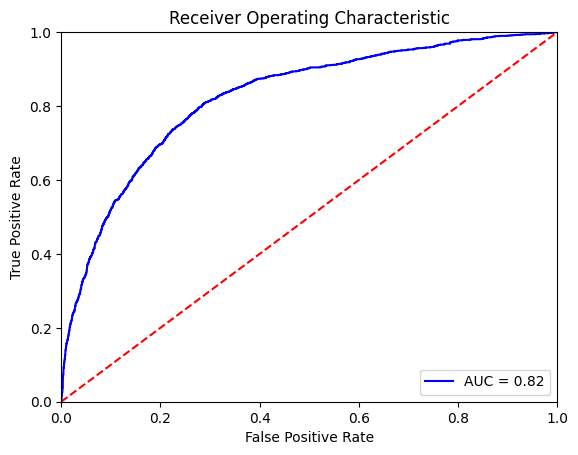

In [60]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.288700,0.323981,0.914487
2,0.290400,0.276792,0.931149
3,0.265600,0.283956,0.928747
4,0.274800,0.286786,0.931365
5,0.266200,0.279479,0.929848
6,0.272400,0.287299,0.927995
7,0.261300,0.284119,0.928498
8,0.279400,0.286372,0.929247
9,0.239400,0.301206,0.926690
10,0.267300,0.303429,0.926468


{'eval_loss': 0.3034294843673706, 'eval_roc_auc': 0.926468099334843, 'eval_runtime': 23.9759, 'eval_samples_per_second': 271.648, 'eval_steps_per_second': 4.254, 'epoch': 10.0}
test f1 0.7258114374034003
test precision 0.7055288461538461
test recall 0.7472947167409294
test accuracy 0.7055288461538461
test roc_auc 0.9263024605474426



train f1 0.7820422258849383
train precision 0.7698964611342914
train recall 0.7945773524720893
train accuracy 0.8933891277641277
train roc_auc 0.9517585711767445


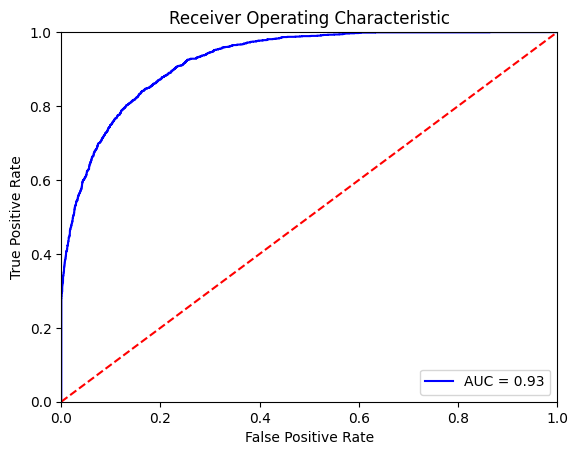

In [61]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()